In [8]:
import sys
sys.path.append('../data/')
from features import block_rms_db, tria_control, TriaStats
import IPython.display as ipd
import soundfile as sf
import torch
import matplotlib.pyplot as plt

In [2]:
audio, sr = sf.read('/data/hai-res/snnithya/sa3-tap/stable-audio-3/cute-SM57.unnormalized(1).wav', frames = 44100 * 12, start = 0*44100)

In [ ]:
# audio = audio.mean(axis=1)

In [3]:
audio = torch.from_numpy(audio)

In [4]:
rms = block_rms_db(audio)

In [5]:
rms.shape

torch.Size([1, 130])

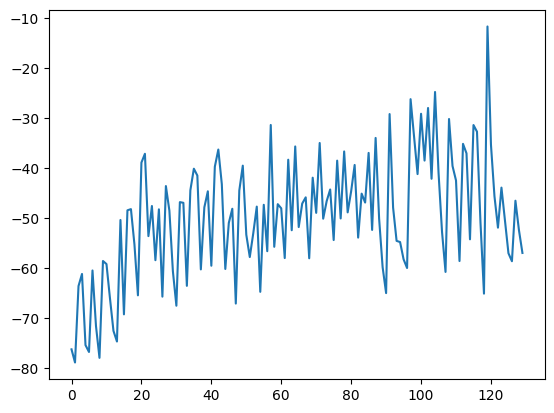

In [6]:
plt.plot(rms[0])

In [11]:
tria_stats = TriaStats.load()
tria = tria_control(audio, stats=tria_stats, norm='ema')

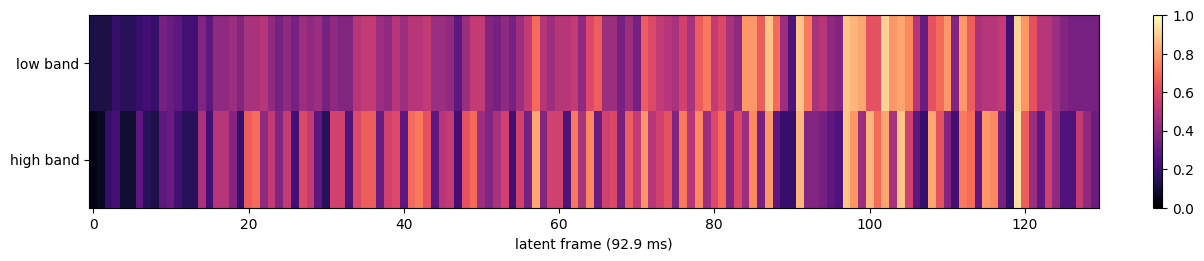

In [17]:
fig, ax = plt.subplots(figsize=(14, 2.5))
im = ax.imshow(tria, aspect="auto", interpolation="nearest", vmin=0, vmax=1, cmap="magma")
ax.set_yticks([0, 1]); ax.set_yticklabels(["low band", "high band"])
ax.set_xlabel("latent frame (92.9 ms)")
fig.colorbar(im, ax=ax, fraction=0.02)

In [16]:
ipd.Audio(audio, rate=44100)